In [1]:
"""
En este script se vera si la muestra de los stamps
es representativa o no.
"""

'\nEn este script se vera si la muestra de los stamps\nes representativa o no.\n'

In [2]:
# Importación de librerías importantes

import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

import astropy 
from pathlib import Path 
from astropy.table import Table 
from astropy.coordinates import SkyCoord 
import astropy.units as u

import os, urllib.request, urllib.error, time, http.client
from astropy.table import unique, vstack

import tarfile, io
import numpy as np
import matplotlib.pyplot as plt
import re

In [3]:

FILE_PATH_COSMOS = "../../data/COSMOS_galaxies_20260618.txt"
df_cosmos = pd.read_csv(FILE_PATH_COSMOS, sep=",")
df_cosmos.info()

<class 'pandas.DataFrame'>
RangeIndex: 641437 entries, 0 to 641436
Data columns (total 55 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ra                  641437 non-null  float64
 1   dec                 641437 non-null  float64
 2   type                641437 non-null  str    
 3   shape_r             641437 non-null  float64
 4   shape_e1            641437 non-null  float64
 5   shape_e2            641437 non-null  float64
 6   sersic              641437 non-null  float64
 7   ebv                 641437 non-null  float64
 8   release             641437 non-null  int64  
 9   brickid             641437 non-null  int64  
 10  objid               641437 non-null  int64  
 11  brick_primary       641437 non-null  bool   
 12  brickname           641437 non-null  str    
 13  maskbits            641437 non-null  int64  
 14  fitbits             641437 non-null  int64  
 15  flux_g              641437 non-null  float64


In [4]:
df_cosmos.columns.tolist()

# se renombra la columna id por desi_id
df_cosmos.rename(columns={"targetid": "desi_id"}, inplace=True)

# se eliminan columnas inutiles
df_cosmos.drop(columns=["zwarn", "spectype", "survey", "release", "dist_deg", "Separation"], inplace=True)

In [5]:
FILE_PATH_FEATURES = "../../data/features_images_20260618.csv"
df_features_images = pd.read_csv(FILE_PATH_FEATURES, sep=",")

In [6]:
print(f"Tamaño df_cosmos: {df_cosmos.shape}")
print(f"Tamaño df_feat: {df_features_images.shape}")

Tamaño df_cosmos: (641437, 49)
Tamaño df_feat: (29575, 48)


In [7]:
#### COMPARACIÓN DISTRIBUCIONES DE MUESTRAS

def compare_dist(col, bins=80, log_x=False, xlabel=None):
    """
    Histogramas normalizados de `col` en df_cosmos y df_features_images.
    log_x=True: aplica log10 filtrando valores <= 0 antes de graficar.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
    label_x = xlabel or (f"log10({col})" if log_x else col)

    for ax, df, title in zip(
        axes,
        [df_cosmos, df_features_images],
        [f"df_cosmos  (n={len(df_cosmos):,})", f"df_features_images  (n={len(df_features_images):,})"],
    ):
        vals = df[col].dropna()
        if log_x:
            vals = np.log10(vals[vals > 0])
        ax.hist(vals, bins=bins, density=True, edgecolor="k", linewidth=0.2)
        ax.set_title(title)
        ax.set_xlabel(label_x)
        ax.set_ylabel("densidad")

    plt.suptitle(col)
    plt.tight_layout()
    plt.show()

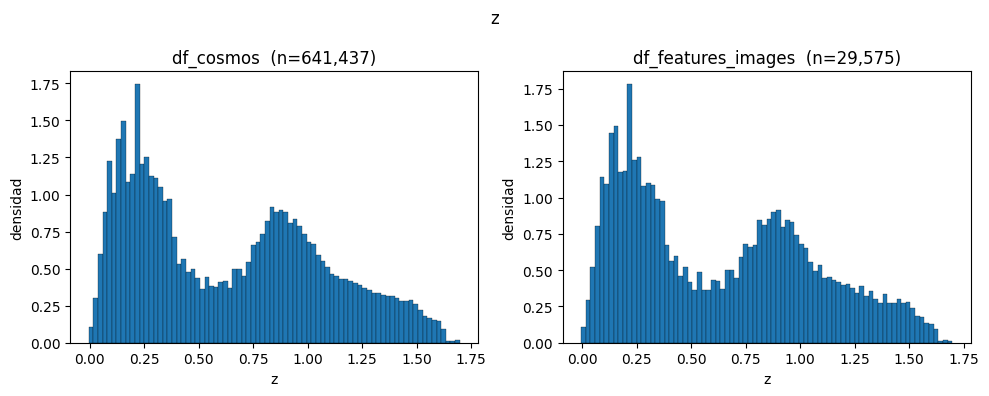

In [8]:
# Redshift espectroscópico
compare_dist("z", bins=80)

Columnas de flujo: ['flux_g', 'flux_r', 'flux_i', 'flux_z', 'flux_w1', 'flux_w2', 'flux_w3', 'flux_w4']


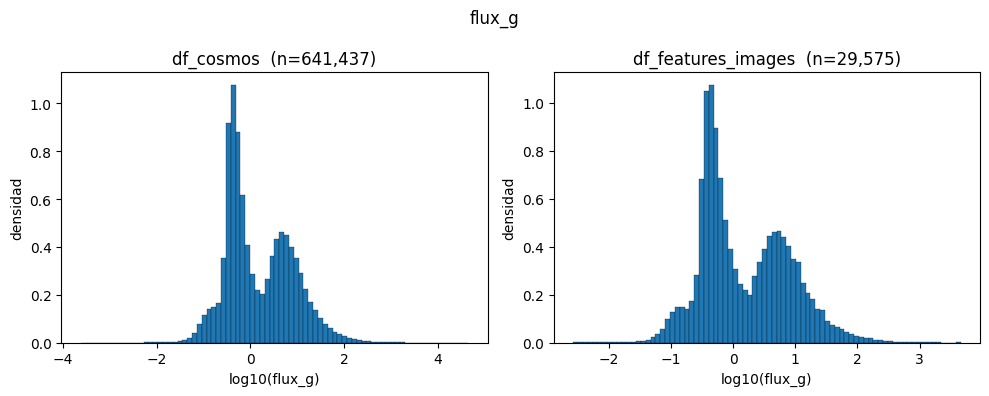

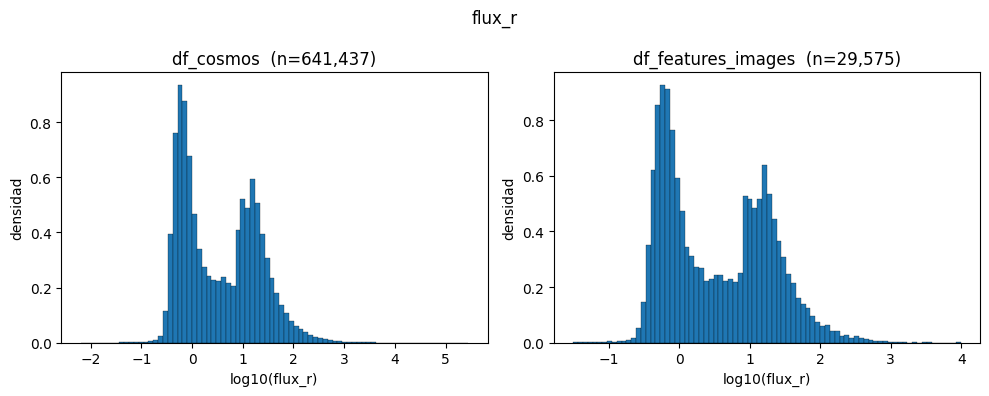

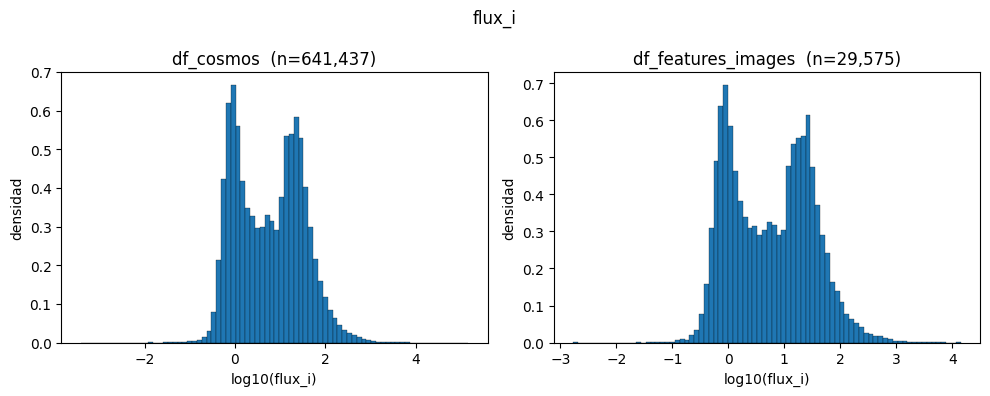

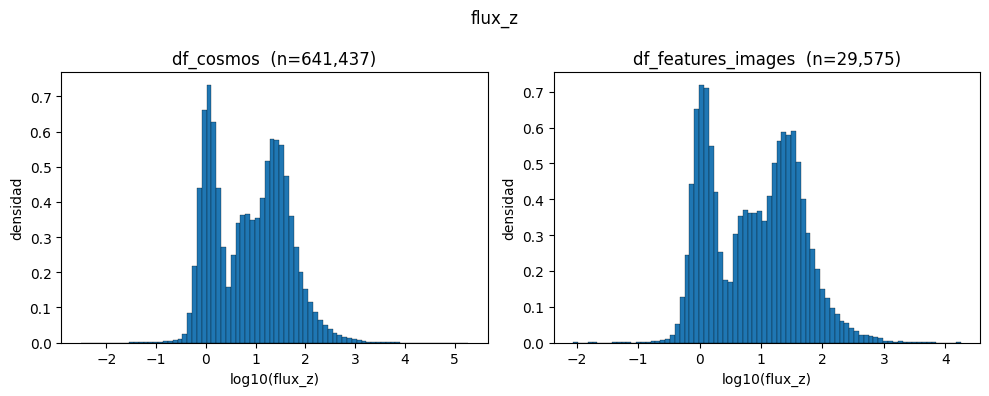

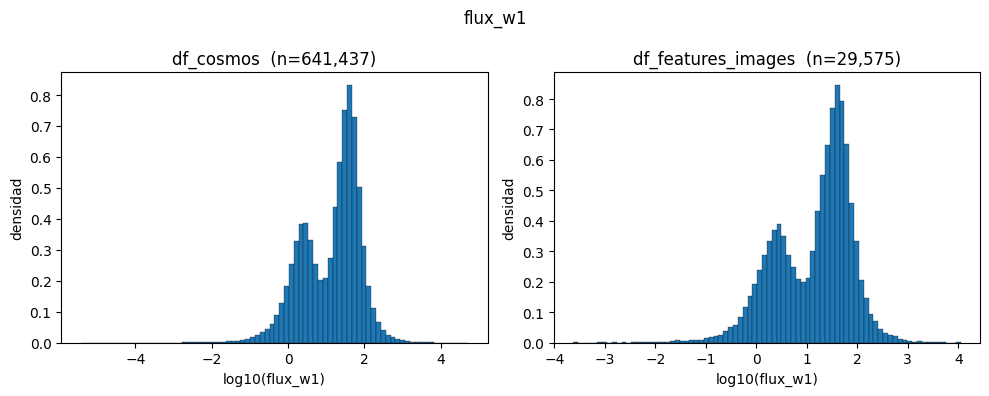

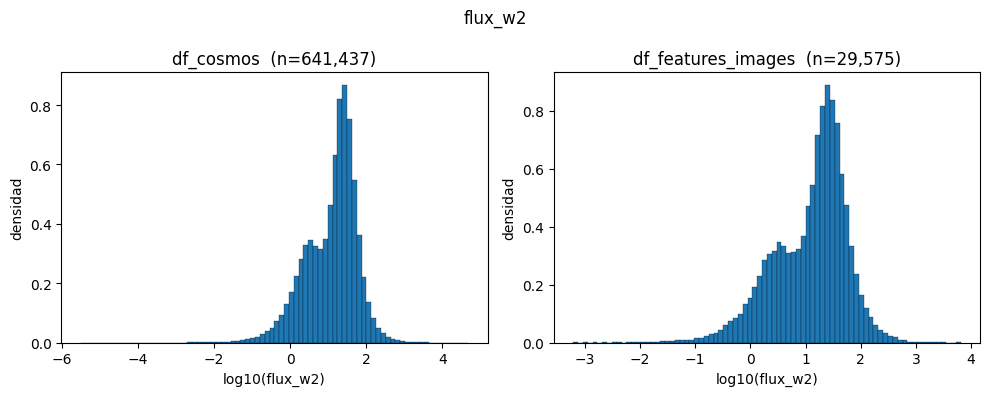

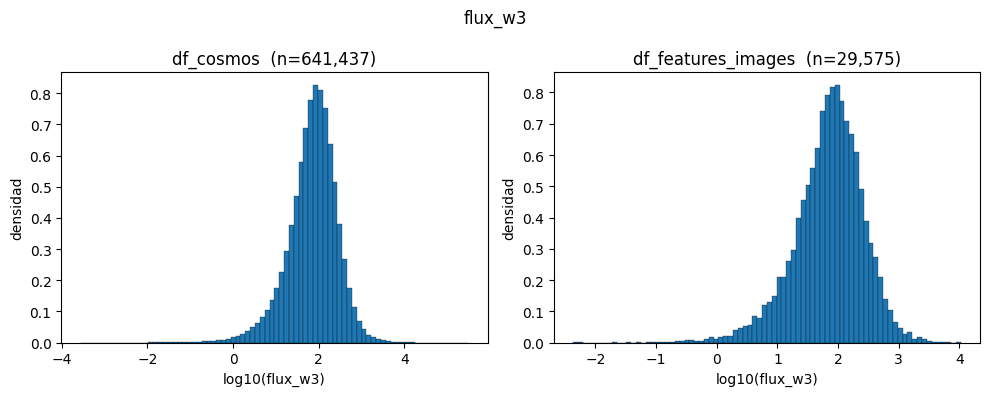

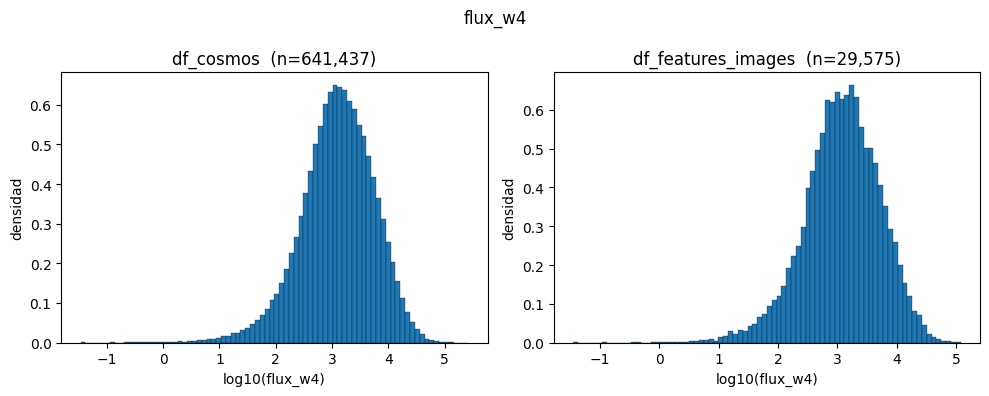

In [9]:
# Flujos por banda (log scale)
flux_cols = [
    c for c in df_cosmos.columns
    if re.fullmatch(r"flux_\w{1,2}", c) and c in df_features_images.columns
]
print(f"Columnas de flujo: {flux_cols}")

for col in flux_cols:
    compare_dist(col, bins=80, log_x=True)

In [10]:
# Fracción de flujos negativos o nulos por banda
neg_frac = pd.DataFrame({
    "df_cosmos":          [(df_cosmos[c] <= 0).mean() for c in flux_cols],
    "df_features_images": [(df_features_images[c] <= 0).mean() for c in flux_cols],
}, index=flux_cols).round(4)
print(neg_frac)

         df_cosmos  df_features_images
flux_g      0.0007              0.0007
flux_r      0.0001              0.0000
flux_i      0.1638              0.0563
flux_z      0.0002              0.0002
flux_w1     0.0574              0.0558
flux_w2     0.1270              0.1243
flux_w3     0.3880              0.3821
flux_w4     0.4814              0.4798


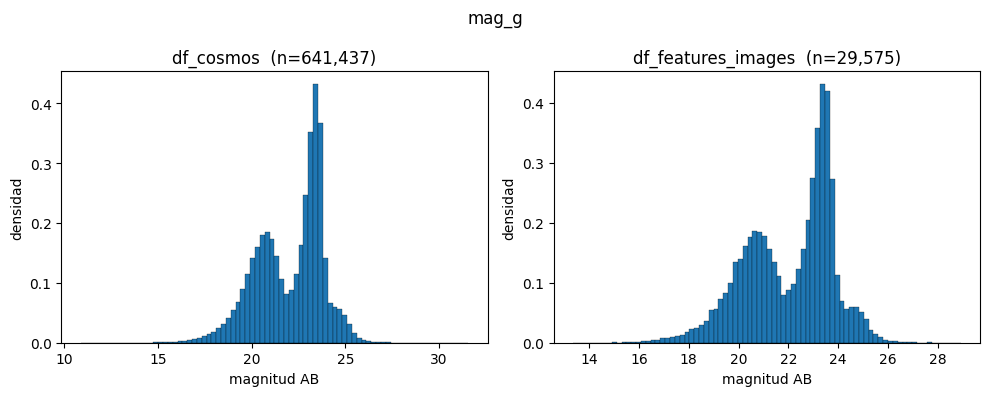

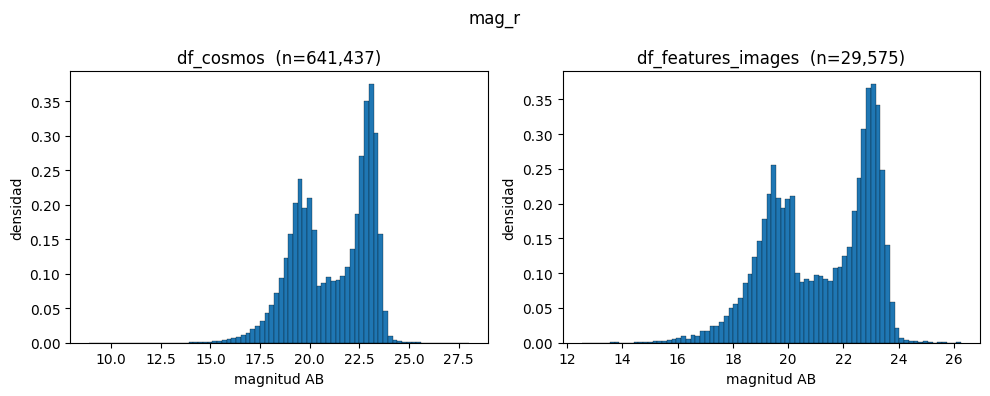

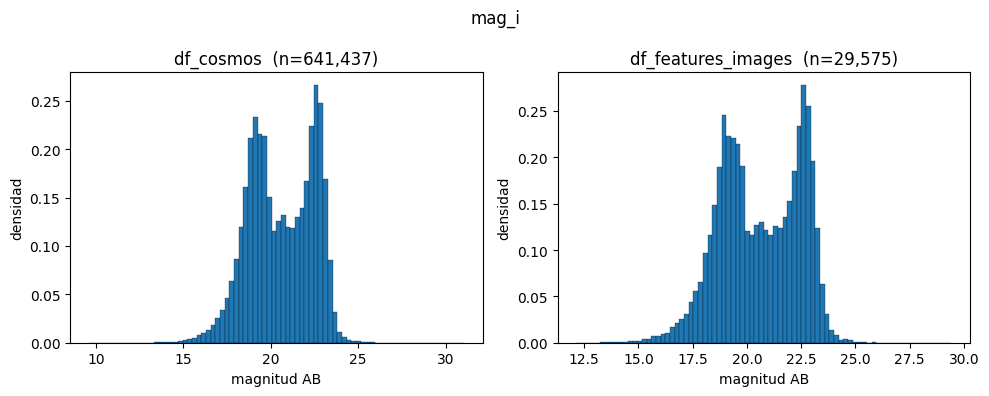

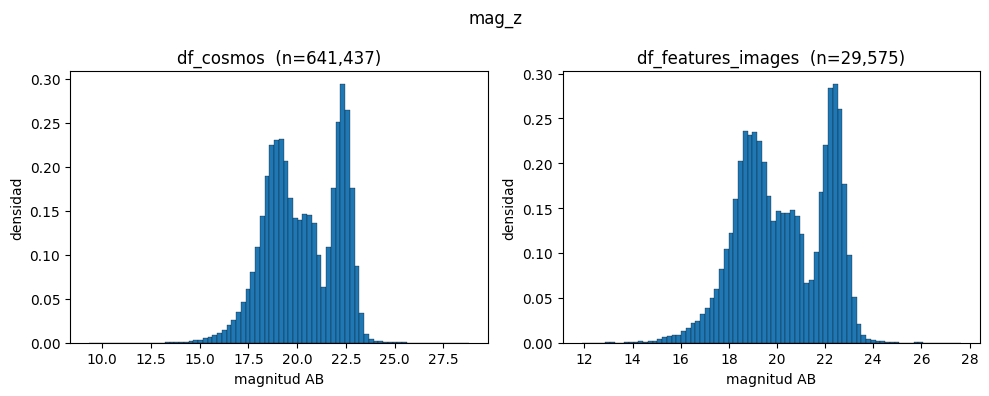

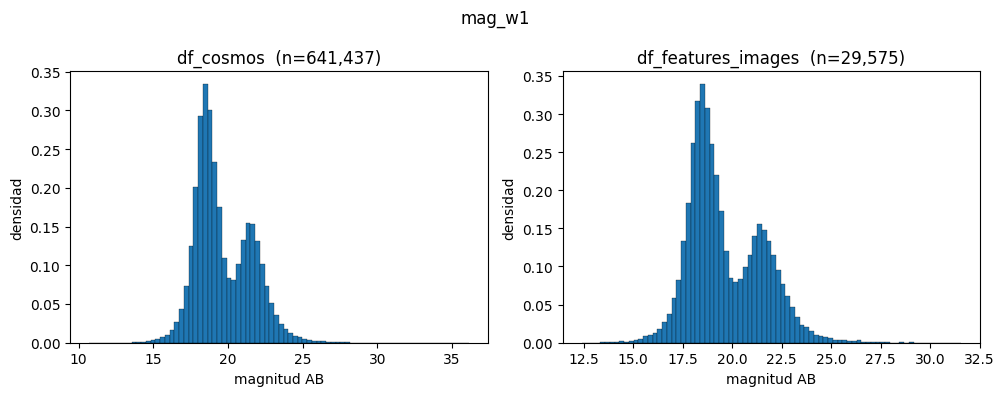

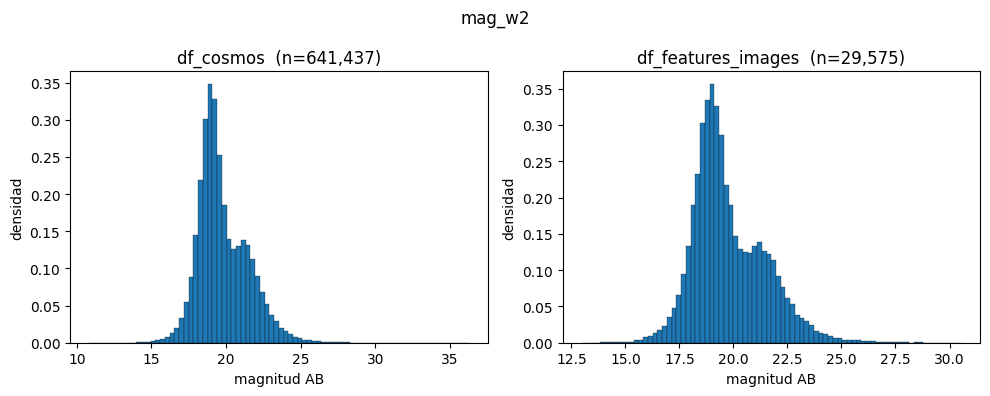

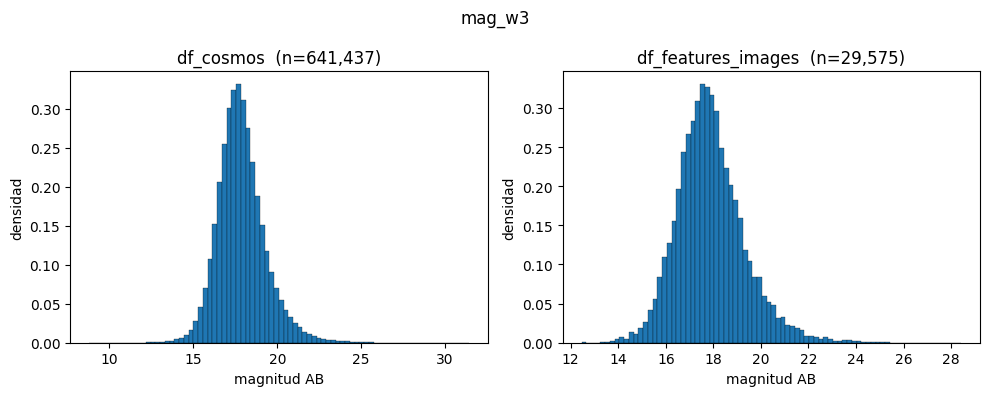

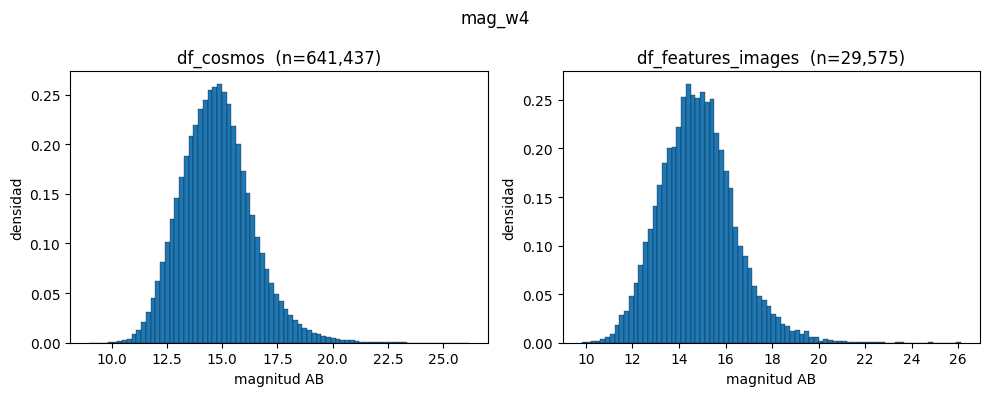

In [11]:
# Magnitudes AB (solo flujo > 0)
def flux_to_mag(flux_series):
    pos = flux_series.copy().astype(float)
    pos[pos <= 0] = np.nan
    return 22.5 - 2.5 * np.log10(pos)

for col in flux_cols:
    mag_col = col.replace("flux_", "mag_")
    df_cosmos[mag_col] = flux_to_mag(df_cosmos[col])
    df_features_images[mag_col] = flux_to_mag(df_features_images[col])
    compare_dist(mag_col, bins=80, xlabel="magnitud AB")